In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ratings = pd.read_csv('../data/ml-100k/u.data',sep='\t',names=['user_id', 'item_id', 'rating', 'timestamp'])

In [3]:
ratings.head(5)

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [4]:
ratings.shape

(100000, 4)

In [9]:
n_users = ratings['user_id'].nunique()
n_items = ratings['item_id'].nunique()
n_ratings = len(ratings)

print(f'Оценок: {n_ratings}')
print(f'Пользователей: {n_users}')
print(f'Фильмов: {n_items}')

Оценок: 100000
Пользователей: 943
Фильмов: 1682


In [11]:
total_cells = n_users * n_items
density = n_ratings / total_cells
sparsity = 1 - density

print(f'Плотность матрицы: {density:.4f} ({density*100:.2f}%)')
print(f'Разреженность: {sparsity:.4f} ({sparsity*100:.2f}%)')

Плотность матрицы: 0.0630 (6.30%)
Разреженность: 0.9370 (93.70%)


In [15]:
print(ratings.dtypes)
print()

print(ratings.isnull().sum())
ratings.describe()

user_id      int64
item_id      int64
rating       int64
timestamp    int64
dtype: object

user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64


,user_id,item_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


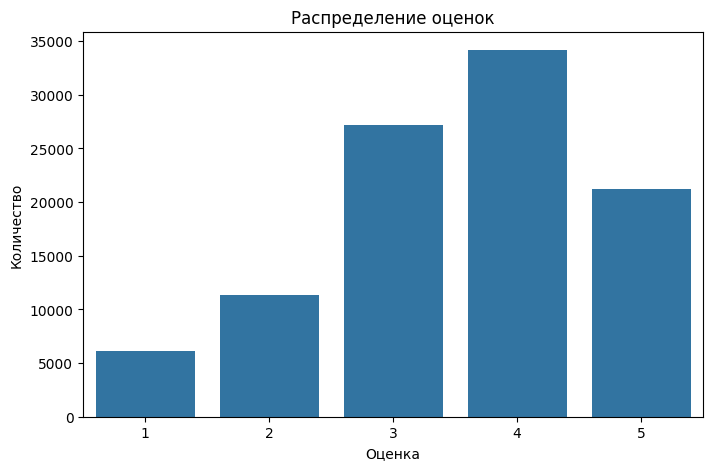

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(x= ratings['rating'], data=ratings)

plt.title('Распределение оценок')
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.show()

**Очевидно, что RMSE будет плох для оценки модели так как если она будет все время давать среднее, то ошибка будет очень маленькой**

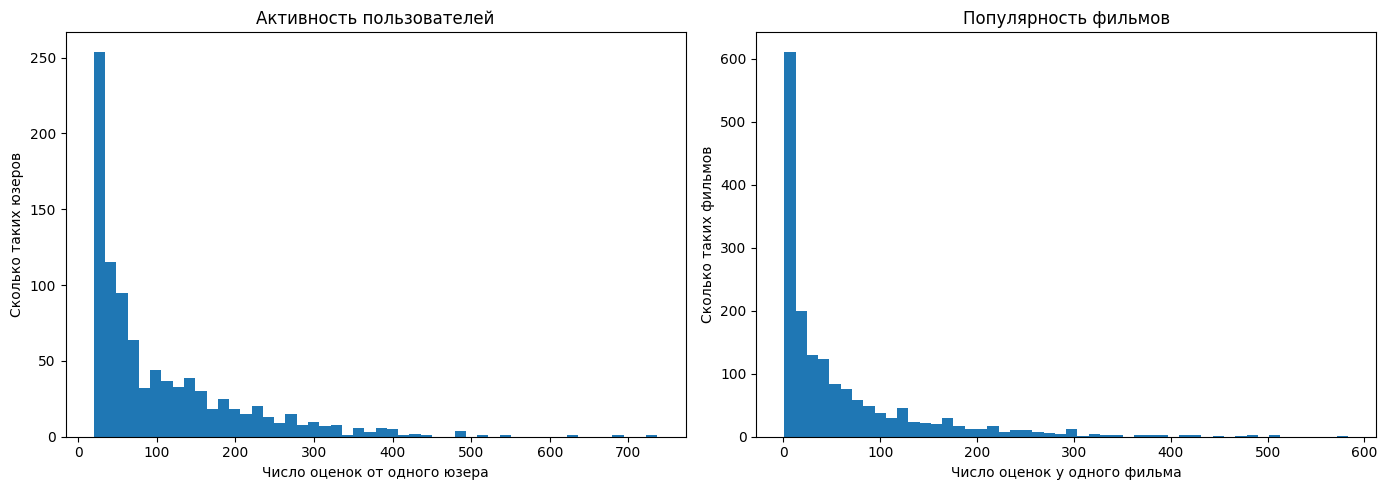

In [18]:
user_activity = ratings.groupby('user_id').size()
item_popularity = ratings.groupby('item_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(user_activity, bins=50)

axes[0].set_title('Активность пользователей')
axes[0].set_xlabel('Число оценок от одного юзера')
axes[0].set_ylabel('Сколько таких юзеров')

axes[1].hist(item_popularity, bins=50)

axes[1].set_title('Популярность фильмов')
axes[1].set_xlabel('Число оценок у одного фильма')
axes[1].set_ylabel('Сколько таких фильмов')

plt.tight_layout()
plt.show()